<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/lectures/machine_learning/mle_cla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Clasificación

<div align="center">
<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2024/08/711091.webp" width="700"/>
</div> 

<br>

> Un problema de **clasificación** consiste en predecir a qué categoría pertenece una observación. A diferencia de la regresión, la variable objetivo es discreta: spam/no spam, churn/no churn, aprobado/reprobado. Este notebook cubre los modelos fundamentales, las métricas correctas para evaluarlos, y un aspecto crítico en la práctica: el desbalance de clases.



## Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)



## 1. El Problema de Clasificación

En clasificación, la variable objetivo $y$ toma valores en un conjunto discreto de clases. El caso más común es la **clasificación binaria**: $y \in \{0, 1\}$.

El modelo aprende a estimar $P(y=1 \mid X)$, la probabilidad de pertenecer a la clase positiva, y luego aplica un **umbral** (por defecto 0.5) para asignar la clase:

$$\hat{y} = \begin{cases} 1 & \text{si } P(y=1 \mid X) \geq 0.5 \\ 0 & \text{si } P(y=1 \mid X) < 0.5 \end{cases}$$

El umbral es un hiperparámetro que podemos ajustar según el costo relativo de los errores.

<!-- IMAGEN SUGERIDA: diagrama mostrando la curva sigmoide de probabilidad con la línea de umbral en 0.5, dividiendo el espacio en clase 0 y clase 1. -->

In [3]:
# Dataset: predicción de churn en clientes de telecomunicaciones
# Features: antigüedad (meses), llamadas al soporte, uso mensual (GB), precio del plan
np.random.seed(42)
n = 1000

antiguedad  = np.random.uniform(1, 60, n)
soporte     = np.random.poisson(2, n).astype(float)
uso_gb      = np.random.normal(15, 5, n).clip(1, 40)
precio_plan = np.random.choice([9990, 14990, 19990, 24990], n).astype(float)

# Probabilidad de churn (mayor soporte y precio alto → más churn)
logit = (-2.5
         - 0.03 * antiguedad
         + 0.5  * soporte
         - 0.05 * uso_gb
         + 0.0001 * precio_plan
         + np.random.normal(0, 0.5, n))
prob_churn = 1 / (1 + np.exp(-logit))
churn = (prob_churn > 0.5).astype(int)

df = pd.DataFrame({
    'churn':       churn,
    'antiguedad':  antiguedad,
    'soporte':     soporte,
    'uso_gb':      uso_gb,
    'precio_plan': precio_plan
})

print(f"Dataset: {df.shape[0]} clientes")
print(f"Churn (1): {churn.sum()} ({churn.mean()*100:.1f}%)")
print(f"No churn (0): {(1-churn).sum()} ({(1-churn).mean()*100:.1f}%)")

Dataset: 1000 clientes
Churn (1): 117 (11.7%)
No churn (0): 883 (88.3%)


In [4]:
# Split train/test
X = df.drop(columns='churn')
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Churn en train: {y_train.mean()*100:.1f}%  |  en test: {y_test.mean()*100:.1f}%")

Train: 800  |  Test: 200
Churn en train: 11.8%  |  en test: 11.5%


> 💡 El parámetro `stratify=y` en `train_test_split` garantiza que la proporción de clases se mantiene igual en train y test. Es buena práctica en clasificación, especialmente con clases desbalanceadas.

---

## 2. Métricas de Clasificación

En clasificación, **accuracy no siempre es la métrica correcta**. Para entender por qué, necesitamos la matriz de confusión.

### 2.1 Matriz de Confusión

Muestra cuántas observaciones fueron clasificadas correctamente e incorrectamente por clase:

|  | Predicho: 0 | Predicho: 1 |
|---|---|---|
| **Real: 0** | Verdadero Negativo (TN) | Falso Positivo (FP) |
| **Real: 1** | Falso Negativo (FN) | Verdadero Positivo (TP) |

### 2.2 Métricas derivadas

| Métrica | Fórmula | Pregunta que responde |
|---|---|---|
| **Accuracy** | $(TP+TN)/(TP+TN+FP+FN)$ | ¿Qué fracción de predicciones son correctas? |
| **Precisión** | $TP/(TP+FP)$ | De los que predije como positivos, ¿cuántos realmente lo son? |
| **Recall** | $TP/(TP+FN)$ | De los positivos reales, ¿cuántos detecté? |
| **F1-score** | $2 \cdot \frac{Prec \cdot Recall}{Prec + Recall}$ | Media armónica de precisión y recall |

### 2.3 ¿Cuándo usar cada métrica?

| Contexto | Métrica preferida | Razón |
|---|---|---|
| Clases balanceadas | Accuracy o F1 | Cualquiera es representativa |
| Detección de fraude | **Recall** | Mejor detectar todos los fraudes, aunque haya falsas alarmas |
| Filtro de spam | **Precisión** | Mejor no marcar correos legítimos como spam |
| Diagnóstico médico | **Recall** | No perder casos positivos es crítico |
| Clases desbalanceadas | **F1 o AUC** | Accuracy es engañosa |

<!-- IMAGEN SUGERIDA: diagrama 2x2 de la matriz de confusión con colores (verde para TN/TP, rojo para FP/FN) y los nombres de cada error. -->

---

## 3. Regresión Logística

La regresión logística estima la probabilidad de la clase positiva usando la función sigmoide:

$$P(y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_k X_k)}}$$

Es el modelo de referencia para clasificación: simple, rápido, interpretable, y robusto. Sus coeficientes se interpretan en términos de **odds ratio**.

In [5]:
# Regresión Logística
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])
lr.fit(X_train, y_train)
y_pred_lr  = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]  # probabilidad de clase 1

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_lr,
                             target_names=['No churn', 'Churn']))

=== Regresión Logística ===
              precision    recall  f1-score   support

    No churn       0.92      0.95      0.94       177
       Churn       0.53      0.39      0.45        23

    accuracy                           0.89       200
   macro avg       0.73      0.67      0.69       200
weighted avg       0.88      0.89      0.88       200



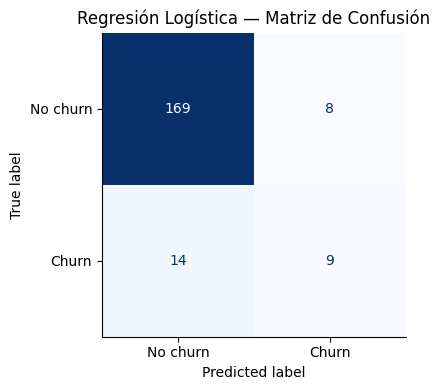

In [6]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['No churn', 'Churn']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Regresión Logística — Matriz de Confusión')
plt.tight_layout()
plt.show()

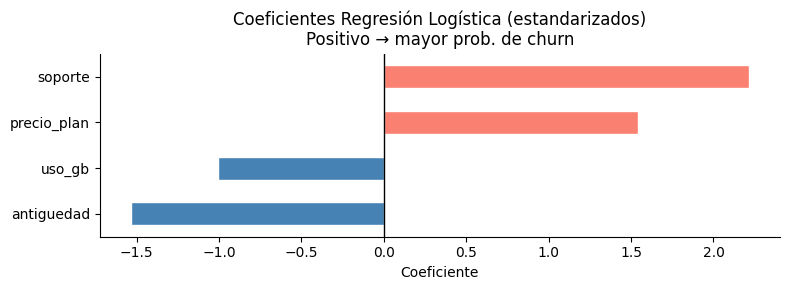

In [7]:
# Coeficientes: dirección e importancia de cada feature
coefs = pd.Series(
    lr.named_steps['model'].coef_[0],
    index=X.columns
).sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
colores = ['salmon' if c > 0 else 'steelblue' for c in coefs]
coefs.plot(kind='barh', color=colores, edgecolor='white', ax=ax)
ax.axvline(0, color='black', lw=1)
ax.set_title('Coeficientes Regresión Logística (estandarizados)\nPositivo → mayor prob. de churn')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

---

## 4. Árbol de Decisión para Clasificación

El árbol divide el espacio de features usando preguntas binarias, buscando maximizar la pureza de cada nodo (criterio Gini o Entropía). Es muy interpretable y puede visualizarse directamente.

In [8]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

print("=== Árbol de Decisión ===")
print(classification_report(y_test, y_pred_tree,
                             target_names=['No churn', 'Churn']))

=== Árbol de Decisión ===
              precision    recall  f1-score   support

    No churn       0.92      0.93      0.92       177
       Churn       0.41      0.39      0.40        23

    accuracy                           0.86       200
   macro avg       0.67      0.66      0.66       200
weighted avg       0.86      0.86      0.86       200



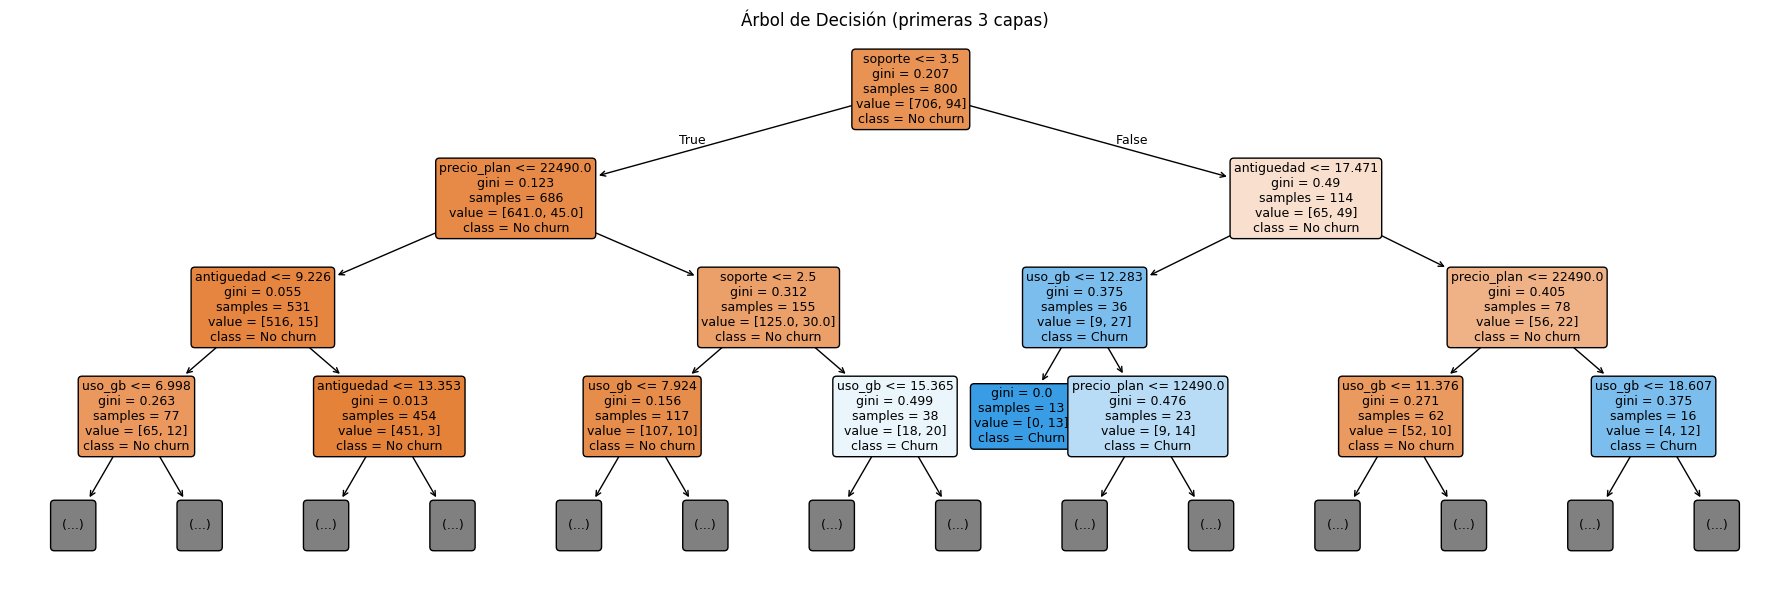

In [9]:
# Visualización del árbol (primeras 3 capas)
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    tree, max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=['No churn', 'Churn'],
    filled=True, rounded=True,
    fontsize=9, ax=ax
)
ax.set_title('Árbol de Decisión (primeras 3 capas)', fontsize=12)
plt.tight_layout()
plt.show()

---

## 5. Curva ROC y AUC

La **curva ROC** (Receiver Operating Characteristic) muestra el trade-off entre la tasa de verdaderos positivos (recall) y la tasa de falsos positivos para distintos umbrales de decisión.

El **AUC** (Area Under the Curve) resume la curva en un solo número:

| AUC | Interpretación |
|---|---|
| 1.0 | Clasificador perfecto |
| 0.5 | Equivalente a clasificar al azar |
| < 0.5 | Peor que el azar (invertir las predicciones mejora el modelo) |

> 💡 AUC mide la capacidad del modelo de **ordenar** correctamente los casos positivos por encima de los negativos, independientemente del umbral. Es especialmente útil con clases desbalanceadas.

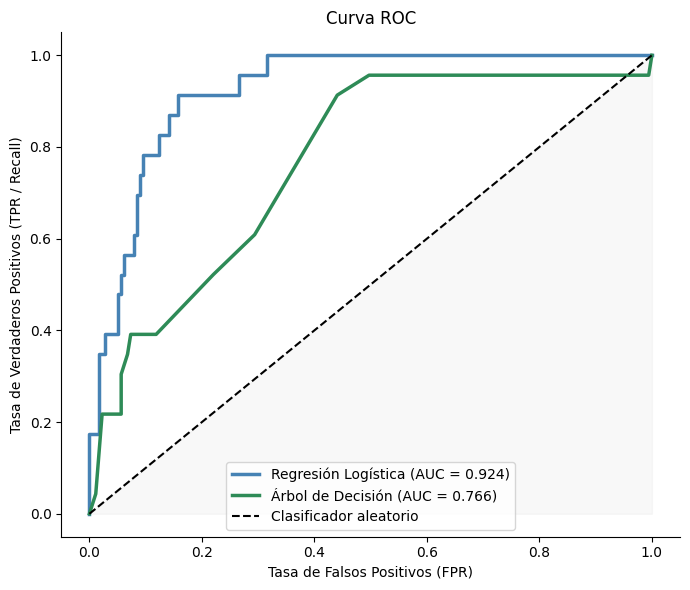

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for nombre, y_prob, color in [
    ('Regresión Logística', y_prob_lr,   'steelblue'),
    ('Árbol de Decisión',  y_prob_tree,  'seagreen'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{nombre} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_title('Curva ROC')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## 6. El Problema del Desbalance de Clases

En muchos problemas reales la clase positiva es minoritaria: fraude (1-2%), churn (5-15%), enfermedades raras. Un modelo que siempre predice la clase mayoritaria puede tener **accuracy alta pero ser inútil**.

**Ejemplo:** si el 95% de los clientes no hace churn, un modelo que siempre predice "no churn" tiene accuracy = 95%, pero recall de churn = 0%.

In [11]:
# Simulamos un dataset muy desbalanceado: 5% de churn
np.random.seed(99)
n_desbal = 2000

antiguedad_d  = np.random.uniform(1, 60, n_desbal)
soporte_d     = np.random.poisson(2, n_desbal).astype(float)
uso_gb_d      = np.random.normal(15, 5, n_desbal).clip(1, 40)
precio_plan_d = np.random.choice([9990, 14990, 19990, 24990], n_desbal).astype(float)

logit_d = (-4.0
           - 0.03 * antiguedad_d
           + 0.5  * soporte_d
           - 0.05 * uso_gb_d
           + 0.0001 * precio_plan_d
           + np.random.normal(0, 0.5, n_desbal))
prob_d = 1 / (1 + np.exp(-logit_d))
churn_d = (prob_d > 0.5).astype(int)

df_d = pd.DataFrame({
    'churn': churn_d,
    'antiguedad': antiguedad_d,
    'soporte': soporte_d,
    'uso_gb': uso_gb_d,
    'precio_plan': precio_plan_d
})

print(f"Churn: {churn_d.sum()} ({churn_d.mean()*100:.1f}%)")
print(f"No churn: {(1-churn_d).sum()} ({(1-churn_d).mean()*100:.1f}%)")

Churn: 20 (1.0%)
No churn: 1980 (99.0%)


In [12]:
X_d = df_d.drop(columns='churn')
y_d = df_d['churn']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
)

# Modelo sin ajuste por desbalance
lr_desbal = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(random_state=42, max_iter=1000))
])
lr_desbal.fit(X_train_d, y_train_d)
y_pred_desbal = lr_desbal.predict(X_test_d)

# Modelo con class_weight='balanced'
lr_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(class_weight='balanced',
                                  random_state=42, max_iter=1000))
])
lr_balanced.fit(X_train_d, y_train_d)
y_pred_balanced = lr_balanced.predict(X_test_d)

print("=== Sin ajuste por desbalance ===")
print(classification_report(y_test_d, y_pred_desbal,
                             target_names=['No churn', 'Churn']))
print("=== Con class_weight='balanced' ===")
print(classification_report(y_test_d, y_pred_balanced,
                             target_names=['No churn', 'Churn']))

=== Sin ajuste por desbalance ===
              precision    recall  f1-score   support

    No churn       0.99      1.00      0.99       396
       Churn       0.00      0.00      0.00         4

    accuracy                           0.99       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.98      0.99      0.98       400

=== Con class_weight='balanced' ===
              precision    recall  f1-score   support

    No churn       1.00      0.95      0.97       396
       Churn       0.13      0.75      0.22         4

    accuracy                           0.95       400
   macro avg       0.56      0.85      0.60       400
weighted avg       0.99      0.95      0.97       400



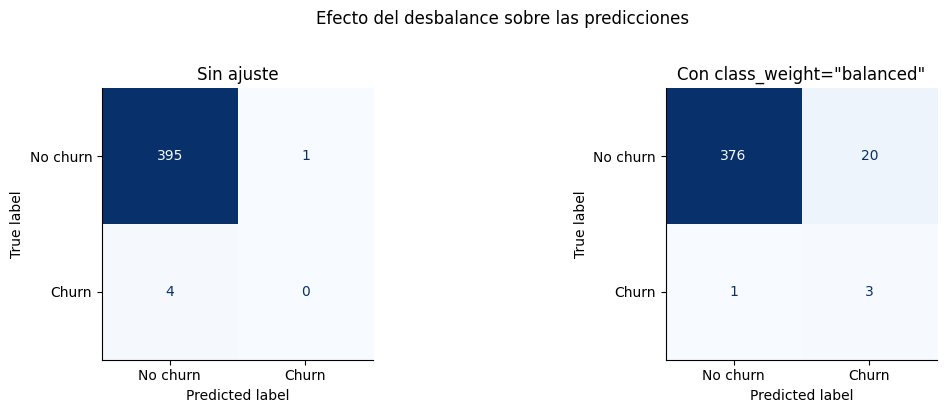

In [13]:
# Comparación visual: matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titulo in [
    (axes[0], y_pred_desbal,   'Sin ajuste'),
    (axes[1], y_pred_balanced, 'Con class_weight="balanced"'),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test_d, y_pred),
        display_labels=['No churn', 'Churn']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)

plt.suptitle('Efecto del desbalance sobre las predicciones', y=1.02)
plt.tight_layout()
plt.show()

**Estrategias para manejar el desbalance:**

| Estrategia | Cómo funciona | Cuándo usarla |
|---|---|---|
| `class_weight='balanced'` | Penaliza más los errores en la clase minoritaria durante el entrenamiento | Primera opción, sin costo adicional |
| Ajustar el umbral | Bajar el umbral de 0.5 aumenta recall de la clase positiva | Cuando el costo de FN es alto |
| Oversampling (SMOTE) | Genera ejemplos sintéticos de la clase minoritaria | Cuando el desbalance es extremo (< 5%) |
| Undersampling | Reduce la clase mayoritaria | Con datasets muy grandes |

---

## 7. Efecto del Umbral de Decisión

El umbral por defecto (0.5) no siempre es el óptimo. Bajarlo aumenta el recall pero disminuye la precisión, y viceversa. La elección depende del contexto.

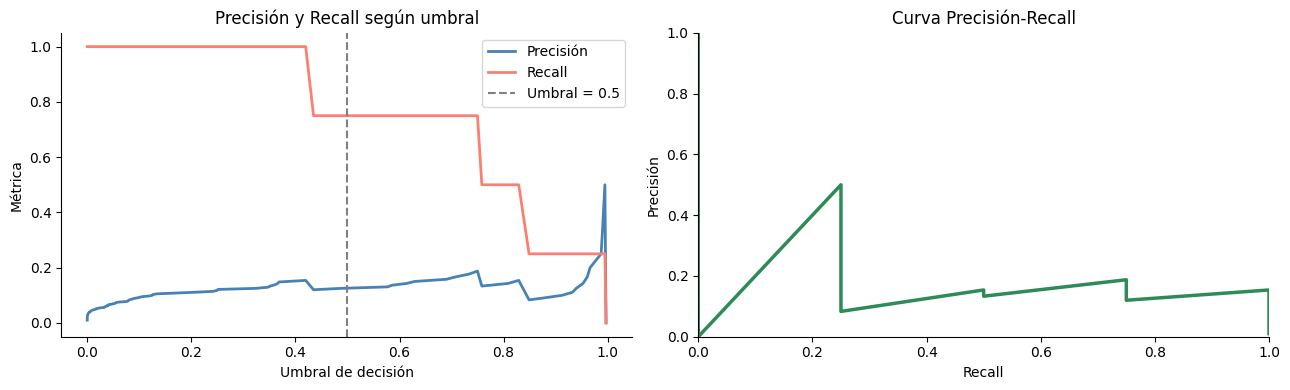

In [14]:
# Curva Precisión-Recall según umbral
from sklearn.metrics import precision_recall_curve

y_prob_bal = lr_balanced.predict_proba(X_test_d)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test_d, y_prob_bal)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Precisión y Recall vs umbral
ax = axes[0]
ax.plot(thresholds, prec[:-1], color='steelblue', lw=2, label='Precisión')
ax.plot(thresholds, rec[:-1],  color='salmon',    lw=2, label='Recall')
ax.axvline(0.5, color='gray', lw=1.5, linestyle='--', label='Umbral = 0.5')
ax.set_title('Precisión y Recall según umbral')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Métrica')
ax.legend()

# Curva Precisión-Recall
ax = axes[1]
ax.plot(rec, prec, color='seagreen', lw=2.5)
ax.set_title('Curva Precisión-Recall')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisión')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [15]:
# Comparación de métricas para distintos umbrales
umbrales = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for u in umbrales:
    y_pred_u = (y_prob_bal >= u).astype(int)
    rows.append({
        'Umbral': u,
        'Accuracy':  accuracy_score(y_test_d, y_pred_u),
        'Precisión': precision_score(y_test_d, y_pred_u, zero_division=0),
        'Recall':    recall_score(y_test_d, y_pred_u),
        'F1':        f1_score(y_test_d, y_pred_u, zero_division=0),
    })

pd.DataFrame(rows).set_index('Umbral').round(3)

,Accuracy,Precisión,Recall,F1
Umbral,,,,
0.3,0.930,0.125,1.00,0.222
0.4,0.945,0.154,1.00,0.267
0.5,0.948,0.130,0.75,0.222
0.6,0.952,0.143,0.75,0.240
0.7,0.960,0.167,0.75,0.273


---

## 8. Comparación de Modelos

Volvemos al dataset balanceado original para comparar ambos modelos en igualdad de condiciones.

In [16]:
# Función de evaluación para clasificación
def evaluar_clasificador(nombre, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"{'Modelo':<25} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
    print("-" * 55)
    print(f"{nombre:<25} {acc:>6.3f} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f} {auc:>6.3f}")
    return {'modelo': nombre, 'Accuracy': acc, 'Precisión': prec,
            'Recall': rec, 'F1': f1, 'AUC': auc}

resultados = []
resultados.append(evaluar_clasificador(
    'Regresión Logística', y_test, y_pred_lr, y_prob_lr))
print()
resultados.append(evaluar_clasificador(
    'Árbol de Decisión', y_test, y_pred_tree, y_prob_tree))

Modelo                       Acc   Prec    Rec     F1    AUC
-------------------------------------------------------
Regresión Logística        0.890  0.529  0.391  0.450  0.924

Modelo                       Acc   Prec    Rec     F1    AUC
-------------------------------------------------------
Árbol de Decisión          0.865  0.409  0.391  0.400  0.766


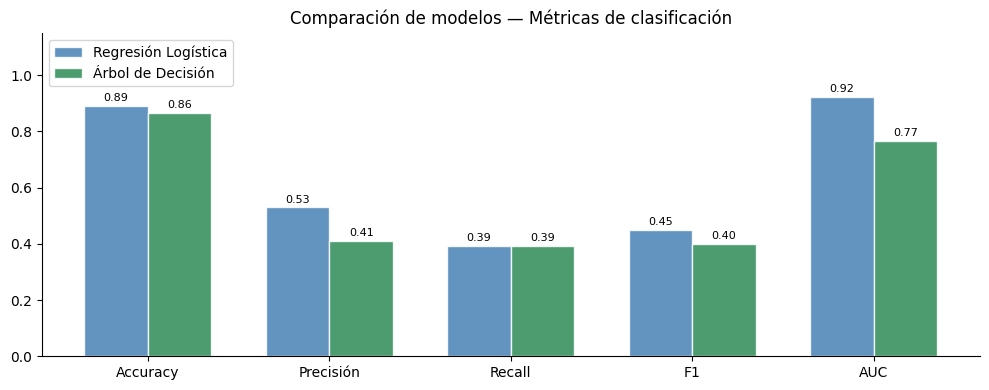

In [17]:
# Resumen visual: métricas lado a lado
df_res = pd.DataFrame(resultados).set_index('modelo')
metricas = ['Accuracy', 'Precisión', 'Recall', 'F1', 'AUC']

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(metricas))
ancho = 0.35
colores = ['steelblue', 'seagreen']

for i, (modelo, color) in enumerate(zip(df_res.index, colores)):
    valores = df_res.loc[modelo, metricas].values
    bars = ax.bar(x + i*ancho, valores, ancho, label=modelo,
                  color=color, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + ancho/2)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.15)
ax.set_title('Comparación de modelos — Métricas de clasificación')
ax.legend()
plt.tight_layout()
plt.show()

---

## Resumen

| Concepto | Idea central |
|---|---|
| Clasificación binaria | Predecir $P(y=1 \mid X)$ y aplicar un umbral para asignar la clase |
| Matriz de confusión | Base de todas las métricas: TN, FP, FN, TP |
| Accuracy | Útil solo con clases balanceadas |
| Precisión | Cuántos de los que predije positivos son realmente positivos |
| Recall | Cuántos de los positivos reales detecté |
| F1-score | Balance entre precisión y recall |
| AUC-ROC | Capacidad del modelo de ordenar positivos sobre negativos; robusto al desbalance |
| Desbalance de clases | Accuracy es engañosa; usar `class_weight='balanced'` o ajustar el umbral |
| Umbral de decisión | Parámetro ajustable según el costo relativo de FP vs FN |

---

## Referencias

1. James, G., Witten, D., Hastie, T., Tibshirani, R. (2021). *An Introduction to Statistical Learning*. Springer. Cap. 4.
2. Scikit-learn — Classification metrics: [https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
3. Scikit-learn — LogisticRegression: [https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)